<a href="https://colab.research.google.com/github/NirajChandaliya/docs/blob/main/Copy_of_Coca_Cola_Stock_Price_Analysis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip yfinance pandas
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ERROR: unknown command "yfinance"


In [ ]:
ticker = "KO"
import datetime
end_date = datetime.date.today()
data = yf.download(ticker, start="1962-01-01", end = end_date, interval = '1d')

/tmp/ipython-input-2384532663.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="1962-01-01", end = end_date, interval = '1d')
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Reset index for easier handling
data.reset_index(inplace=True)

In [ ]:
# Data display
data.head()
data.info()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16121 entries, 0 to 16120
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   (Date, )      16121 non-null  datetime64[ns]
 1   (Close, KO)   16121 non-null  float64       
 2   (High, KO)    16121 non-null  float64       
 3   (Low, KO)     16121 non-null  float64       
 4   (Open, KO)    16121 non-null  float64       
 5   (Volume, KO)  16121 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 755.8 KB


MultiIndex([(  'Date',   ''),
            ( 'Close', 'KO'),
            (  'High', 'KO'),
            (   'Low', 'KO'),
            (  'Open', 'KO'),
            ('Volume', 'KO')],
           names=['Price', 'Ticker'])

In [ ]:
# Data Cleaning - Checking the missing value
print(data.isnull().sum())

Price   Ticker
Date              0
Close   KO        0
High    KO        0
Low     KO        0
Open    KO        0
Volume  KO        0
dtype: int64


In [ ]:
# filling missing value with column mean
data.fillna(data.mean(), inplace=True)
data.fillna(0, inplace=True)
print(data.isnull().sum())

Price   Ticker
Date              0
Close   KO        0
High    KO        0
Low     KO        0
Open    KO        0
Volume  KO        0
dtype: int64


In [ ]:
df = pd.read_csv("/content/coca_cola_KO_1962_2025 (1).csv")
df = pd.read_csv("/content/KO_stock_data (1).csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   16123 non-null  object
 1   Close   16122 non-null  object
 2   High    16122 non-null  object
 3   Low     16122 non-null  object
 4   Open    16122 non-null  object
 5   Volume  16122 non-null  object
dtypes: object(6)
memory usage: 755.9+ KB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')
plt.style.use("fivethirtyeight")
sns.set_style("whitegrid")

In [ ]:
# data = pd.read_csv("/content/KO_stock_data (1).csv")
data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,KO,KO,KO,KO,KO
1,Date,NaN,NaN,NaN,NaN,NaN
2,1962-01-02,0.04505200684070587,0.04627859478246026,0.04505200684070587,0.04505200684070587,806400
3,1962-01-03,0.04404829815030098,0.044382995936670354,0.04337925480504689,0.044382995936670354,1574400
4,1962-01-04,0.04438299313187599,0.04471751223098994,0.04415997699596948,0.04415997699596948,844800


In [ ]:
# Read the CSV
data = pd.read_csv("/content/KO_stock_data (1).csv")

# Drop the first two rows (Ticker row and Date label row)
data = data.iloc[2:].reset_index(drop=True)

# Rename columns properly
data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Convert numeric columns to float
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
data[numeric_cols] = data[numeric_cols].astype(float)

# Set Date as index
data.set_index('Date', inplace=True)

# Check result
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
1962-01-02,0.045052,0.046279,0.045052,0.045052,806400.0
1962-01-03,0.044048,0.044383,0.043379,0.044383,1574400.0
1962-01-04,0.044383,0.044718,0.044160,0.044160,844800.0
1962-01-05,0.043379,0.044941,0.043268,0.044383,1420800.0
1962-01-08,0.042933,0.043045,0.042097,0.043045,2035200.0


In [ ]:
data = pd.read_csv("/content/coca_cola_KO_1962_2025 (1).csv")
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1962-01-02 00:00:00-05:00,0.045052,0.046279,0.045052,0.045052,806400,0.0,0.0
1,1962-01-03 00:00:00-05:00,0.044383,0.044383,0.043379,0.044048,1574400,0.0,0.0
2,1962-01-04 00:00:00-05:00,0.044160,0.044717,0.044160,0.044383,844800,0.0,0.0
3,1962-01-05 00:00:00-05:00,0.044383,0.044941,0.043268,0.043379,1420800,0.0,0.0
4,1962-01-08 00:00:00-05:00,0.043045,0.043045,0.042097,0.042933,2035200,0.0,0.0


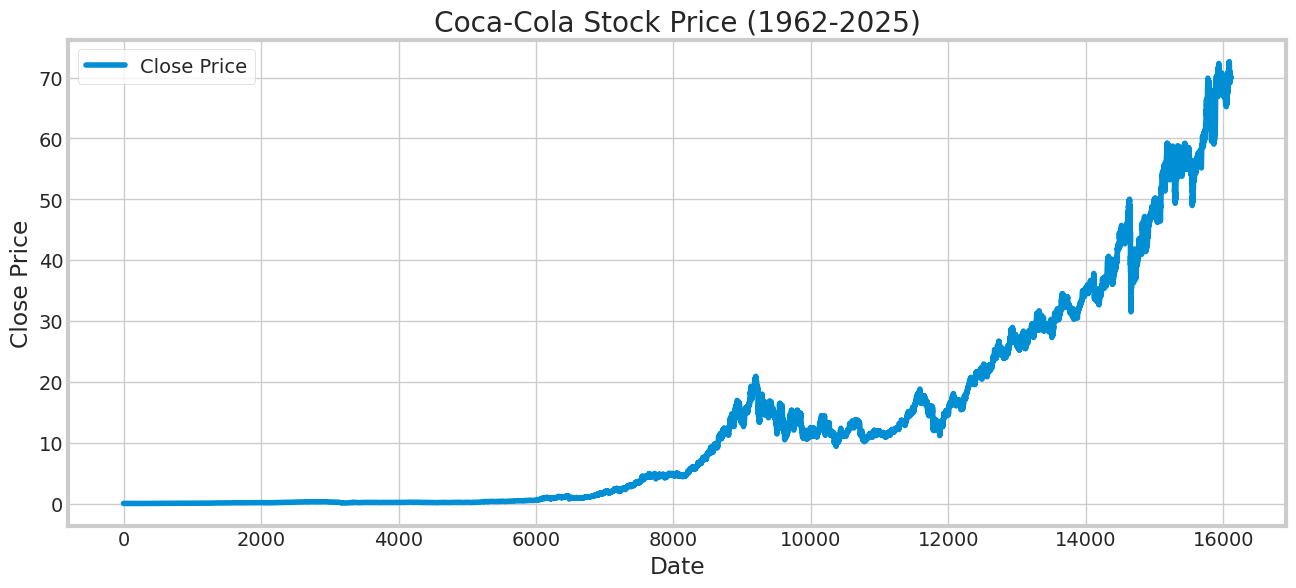

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(data.index, data['Close'], label='Close Price')
plt.title('Coca-Cola Stock Price (1962-2025)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
print(data.index.max())

16107


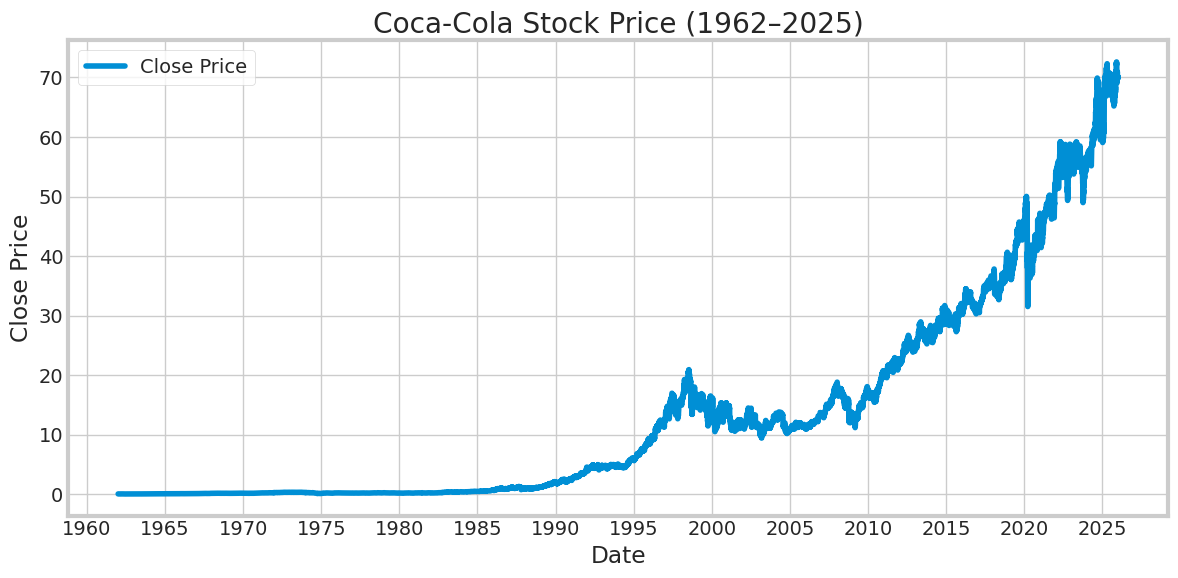

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# the 'Date' column is datetime and set it as index

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Close Price')

plt.title(
    f"Coca-Cola Stock Price ({data.index.min().year}–{data.index.max().year})"
)
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Moving Average
data['MA_50'] = data['Close'].rolling(50).mean()
data['MA_200'] = data['Close'].rolling(200).mean()

In [ ]:
# Daily return & Volatility
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility'] = data['Daily_Return'].rolling(20).std()
data.dropna(inplace=True)

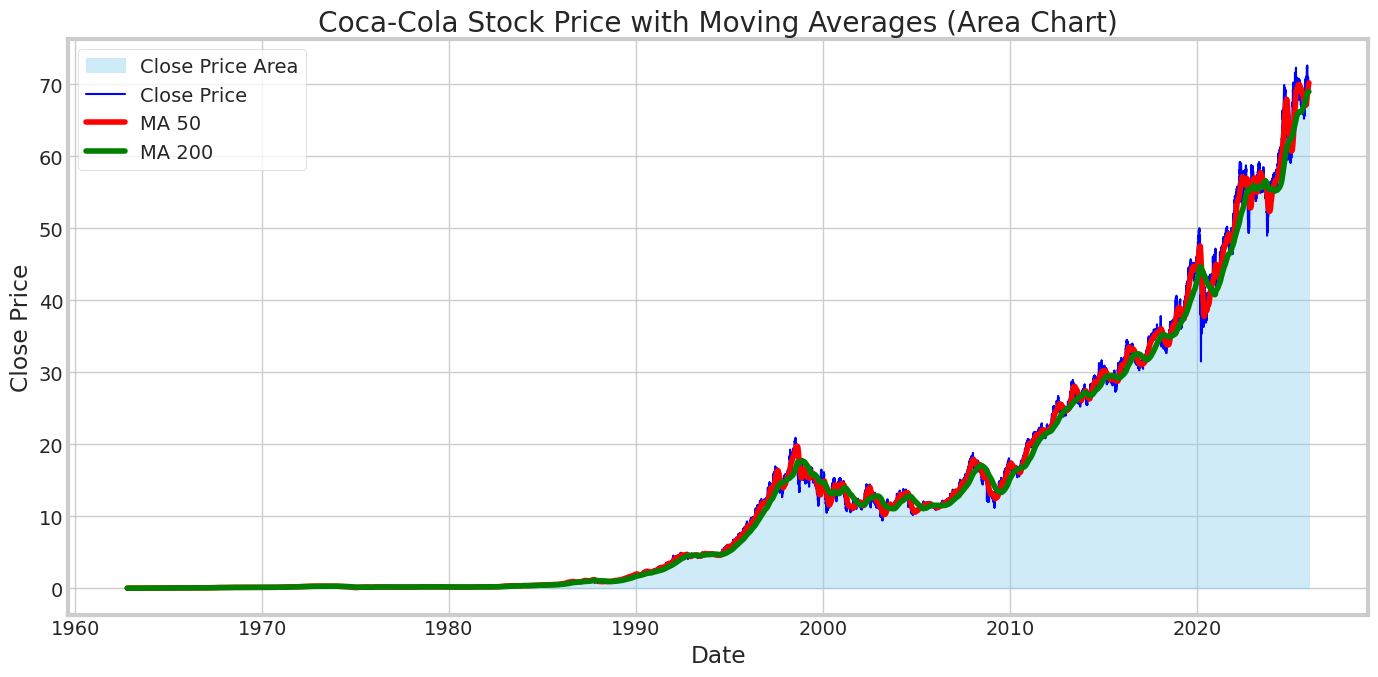

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,7))
plt.fill_between(data.index, data['Close'], color='skyblue', alpha=0.4, label='Close Price Area')
plt.plot(data.index, data['Close'], color='blue', linewidth=1.5, label='Close Price')
plt.plot(data.index, data['MA_50'], label='MA 50', color='red', linestyle='-')
plt.plot(data.index, data['MA_200'], label='MA 200', color='green', linestyle='-')
plt.title('Coca-Cola Stock Price with Moving Averages (Area Chart)')
plt.xlabel('Date')
plt.ylabel('Close Price')

# Add date formatting for clarity
plt.gca().xaxis.set_major_locator(mdates.YearLocator(10))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# CAGR
start_price = data['Close'].iloc[0]
end_price = data['Close'].iloc[-1]
years = (data.index[-1] - data.index[0]).days / 365.25
cagr = (end_price / start_price) ** (1 / years) - 1
print(f"CAGR: {cagr*100:.2f}%")

CAGR: 12.68%


# Coca-Cola has delivered stable around 12% annualised growth, consistent with blue-chip stocks.



In [ ]:
# Random Forest
features = ['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits', 'MA_50', 'MA_200', 'Volatility']
target = 'Close'
x = data[features]
y = data[target]

In [ ]:
# Time - series Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

In [ ]:
# Model training
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 0.1257599547659106
MAE: 0.05933152525983098


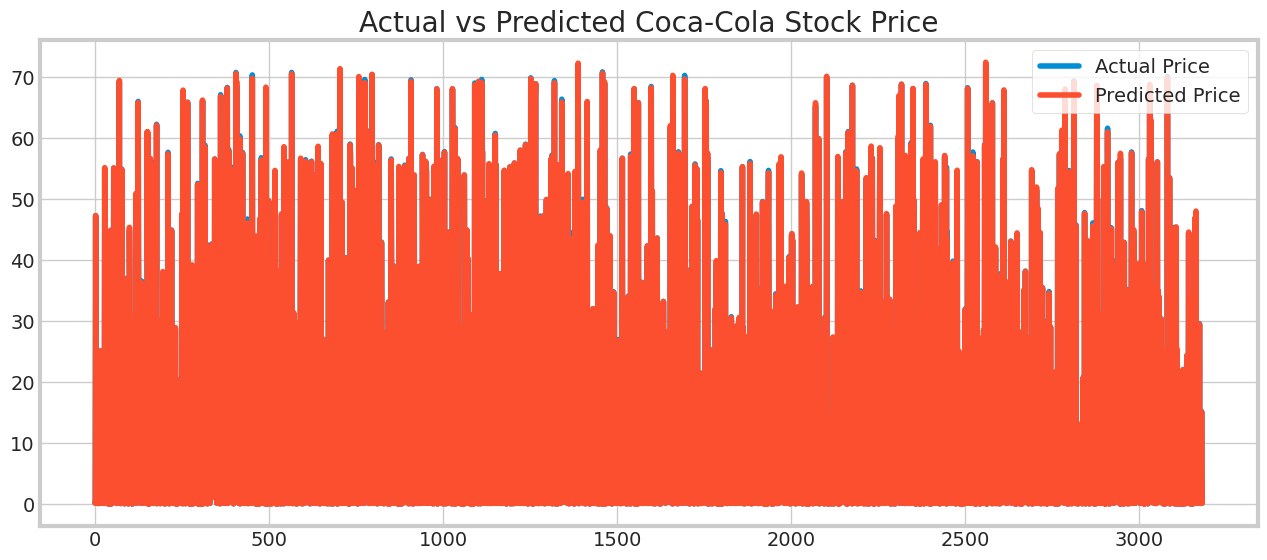

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Coca-Cola Stock Price")
plt.legend()
plt.show()

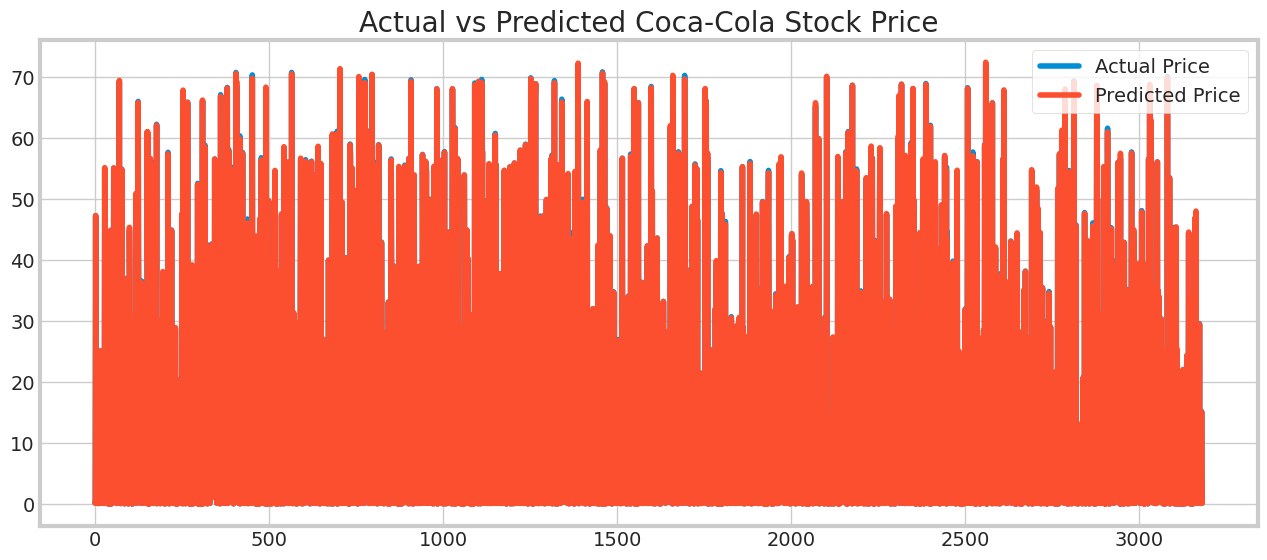

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Coca-Cola Stock Price")
plt.legend()
plt.show()

### Enhanced Visualization: Actual vs. Predicted with Residuals

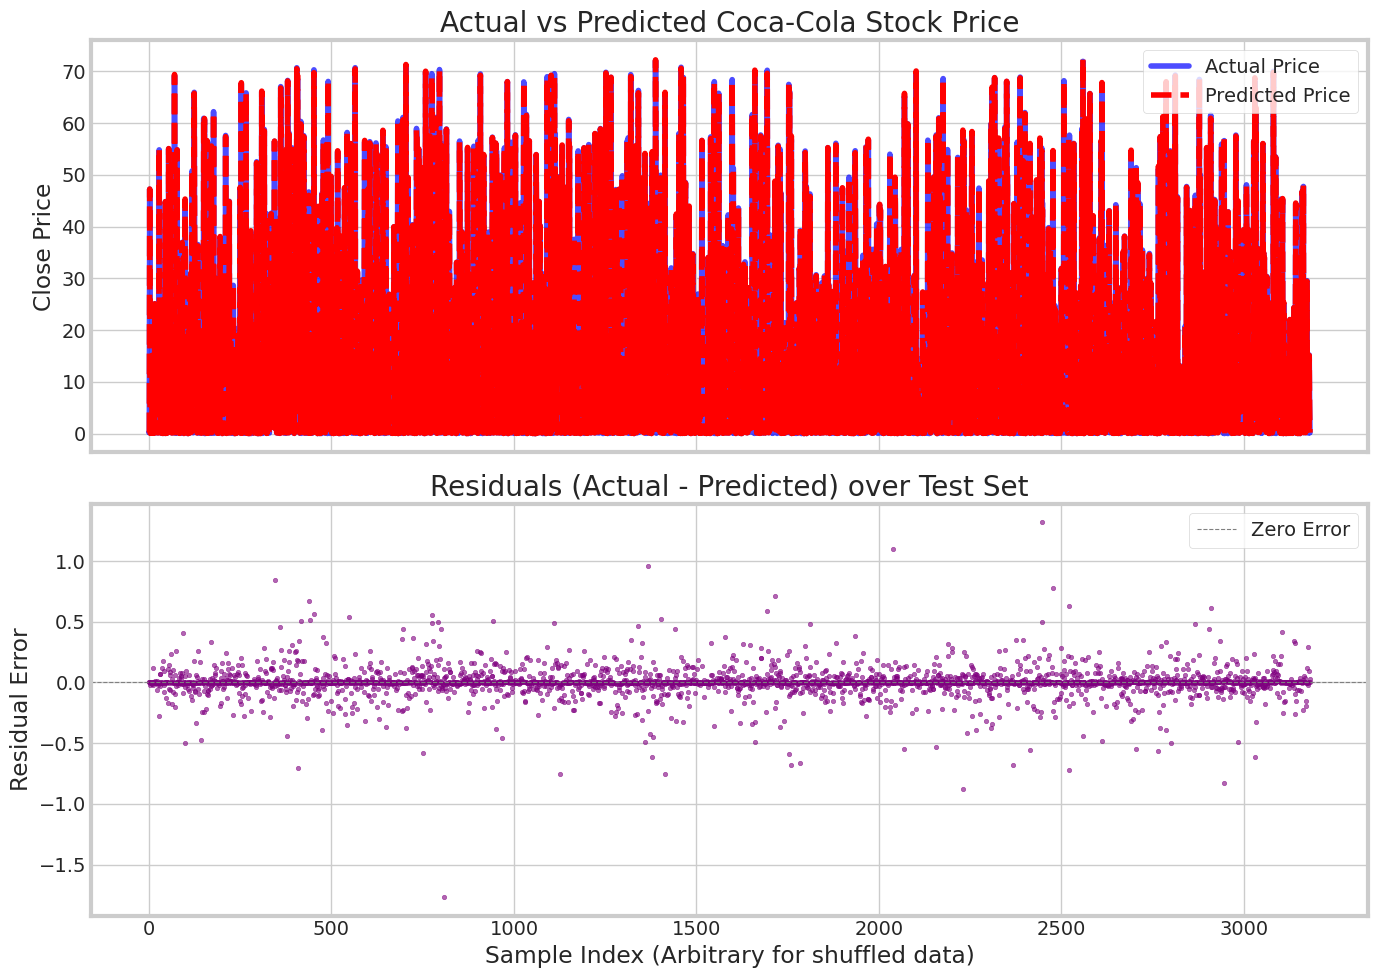

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Actual vs. Predicted Prices
axes[0].plot(y_test.values, label='Actual Price', color='blue', alpha=0.7)
axes[0].plot(y_pred, label='Predicted Price', color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted Coca-Cola Stock Price')
axes[0].set_ylabel('Close Price')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Residual Plot
residuals = y_test.values - y_pred
axes[1].scatter(range(len(y_test)), residuals, alpha=0.6, color='purple', s=10)
axes[1].axhline(y=0, color='grey', linestyle='--', linewidth=0.8, label='Zero Error')
axes[1].set_title('Residuals (Actual - Predicted) over Test Set')
axes[1].set_xlabel('Sample Index (Arbitrary for shuffled data)')
axes[1].set_ylabel('Residual Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Future Price Forecast for next 1 Year
last_date = x.iloc[-1:].values
future_price = model.predict(last_date)
print(f"Predicted future price for the next year: ${future_price[0]:.2f}")



Predicted future price for the next year: $69.98


In [ ]:
# Average annual return
avg_annual_return = data['Daily_Return'].mean() * 252
print(f"Average Annual Return: {avg_annual_return*100:.2f}%")

Average Annual Return: 14.55%


In [ ]:
# Annulised Volatility (Risk Metric)
annual_volatility = data['Daily_Return'].std() * np.sqrt(252)
annual_volatility

np.float64(0.2276567413761865)